# Sprint 10 - Limpieza y análisis de datos con Pandas

En este notebook trabajo con un dataset de trabajadores guardado en el archivo `sprint10.xlsx`.

El objetivo es importar los datos correctamente, hacer algunas tareas de limpieza, crear nuevas columnas y preparar tablas resumen usando pandas.

También se trabajará más adelante con otro archivo, `matriu_distancies.xlsx`, para resolver un ejercicio de rutas entre ciudades.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# Nivel 1

## Ejercicio 1: Importación y primera revisión del dataset

En este primer paso importo el archivo `sprint10.xlsx` como un DataFrame.

El archivo tiene algunas filas informativas antes de la tabla real, por eso indico a pandas cuál es la fila donde empiezan los nombres de las columnas.

Después ordeno el DataFrame por país de origen y, si hay empate, por ciudad.  
Al final compruebo si la columna `DNI` contiene valores únicos.

In [2]:
df = pd.read_excel("sprint10.xlsx", header=3, index_col=0)

df.head()

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A


In [3]:
df.shape

(1000, 13)

In [4]:
df.columns

Index(['Nom', 'Cognoms', 'DNI', 'País d'origen', 'Ciutat', 'Dia de Naixement',
       'Mes de Naixement', 'Any de Naixement', 'Gènere', 'Salari mensual',
       'Fills', 'No Fills', 'Grup Professional'],
      dtype='str')

In [5]:
df_sorted = df.sort_values(
    by=["País d'origen", "Ciutat"],
    ascending=True
)

df_sorted.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [6]:
print(f"El DNI solo contiene valores únicos: {df['DNI'].is_unique}")

El DNI solo contiene valores únicos: True


### Interpretación

El archivo se ha importado correctamente usando la fila donde empiezan los nombres reales de las columnas.

También se ha usado la primera columna del Excel como índice inicial, ya que solo contiene la numeración de las filas.

Después he creado una versión ordenada del DataFrame, primero por país de origen y después por ciudad.  
Con `head(10)` se muestran las primeras 10 filas de esa tabla ordenada.

La comprobación del DNI sirve para ver si hay identificadores repetidos. En este caso, el resultado indica si todos los DNI son únicos dentro del dataset.

## Ejercicio 2: Creación de nuevas columnas y limpieza básica

En este ejercicio creo algunas columnas nuevas y limpio parte de la información del dataset.

Primero creo una columna con el nombre completo de cada persona.  
Después creo una columna para indicar si la persona ha nacido en España o no.

También cambio el índice del DataFrame usando el `DNI`, renombro las columnas de fecha de nacimiento y sustituyo los códigos de género por valores más legibles.

In [7]:
df_clean = df.copy()

In [8]:
df_clean["Nom complet"] = df_clean["Nom"] + " " + df_clean["Cognoms"]

df_clean[["Nom", "Cognoms", "Nom complet"]].head()

,Nom,Cognoms,Nom complet
0,Inês,Ferreira Silva,Inês Ferreira Silva
1,Clara,Sánchez Martínez,Clara Sánchez Martínez
2,Fatima,Fassi,Fatima Fassi
3,Khadija,Bennani Bennani,Khadija Bennani Bennani
4,Toni,Sánchez García,Toni Sánchez García


In [9]:
df_clean["Nascut a Espanya"] = np.where(
    df_clean["País d'origen"] == "Espanya",
    "Sí",
    "No"
)

df_clean[["País d'origen", "Nascut a Espanya"]].head()

# Alternativa possible:
# df_clean["Nascut a Espanya"] = df_clean["País d'origen"].apply(
#     lambda pais: "Sí" if pais == "Espanya" else "No"
# )

#Alternativa 2
#df_clean["Nascut a Espanya"] = df_clean["País d'origen"].eq("Espanya").map({
#   True: "Sí",
#    False: "No"
# })


,País d'origen,Nascut a Espanya
0,Portugal,No
1,Espanya,Sí
2,Marroc,No
3,Marroc,No
4,Espanya,Sí


In [10]:
df_clean = df_clean.set_index("DNI")
df_clean.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut a Espanya
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B,Inês Ferreira Silva,No
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A,Clara Sánchez Martínez,Sí
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A,Fatima Fassi,No
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B,Khadija Bennani Bennani,No
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A,Toni Sánchez García,Sí


In [11]:
df_clean = df_clean.rename(
    columns={
        "Dia de Naixement": "Dia",
        "Mes de Naixement": "Mes",
        "Any de Naixement": "Any"
    }
)

df_clean[["Dia", "Mes", "Any"]].head()

,Dia,Mes,Any
DNI,,,
16928694K,25,2,1953
27724652S,18,3,1996
38141675A,6,11,2005
59157262R,20,1,1995
69630528M,9,8,1999


In [12]:
df_clean["Gènere"] = df_clean["Gènere"].replace({
    "H": "Home",
    "D": "Dona",
    "A": "Altres",
    "NC": np.nan
})

df_clean["Gènere"].value_counts(dropna=False)

Gènere
Home      449
Dona      440
NaN        60
Altres     51
Name: count, dtype: int64

In [13]:
df_clean[
    [
        "Nom",
        "Cognoms",
        "Nom complet",
        "País d'origen",
        "Nascut a Espanya",
        "Ciutat",
        "Dia",
        "Mes",
        "Any",
        "Gènere",
        "Salari mensual",
        "Fills",
        "No Fills",
        "Grup Professional"
    ]
].head(10)

,Nom,Cognoms,Nom complet,País d'origen,Nascut a Espanya,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional
DNI,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Inês Ferreira Silva,Portugal,No,Lisboa,25,2,1953,Dona,1.144 €,NaN,1.0,Grup B
27724652S,Clara,Sánchez Martínez,Clara Sánchez Martínez,Espanya,Sí,Barcelona,18,3,1996,Dona,1.253 €,1.0,NaN,Grup A
38141675A,Fatima,Fassi,Fatima Fassi,Marroc,No,Rabat,6,11,2005,Altres,1.441 €,1.0,NaN,Grup A
59157262R,Khadija,Bennani Bennani,Khadija Bennani Bennani,Marroc,No,Rabat,20,1,1995,Dona,1.944 €,NaN,1.0,Grup B
69630528M,Toni,Sánchez García,Toni Sánchez García,Espanya,Sí,Barcelona,9,8,1999,Home,1.043 €,NaN,1.0,Grup A
26930927E,Laia,Castells Ferrer,Laia Castells Ferrer,Espanya,Sí,Madrid,16,12,1953,Altres,2.611 €,NaN,1.0,Grup D
78247593G,Carla,García,Carla García,Espanya,Sí,València,24,12,1957,Dona,942 €,NaN,1.0,Grup A
21774231J,Marco,Rossi,Marco Rossi,Itàlia,No,Torí,3,11,2002,Altres,1.494 €,NaN,1.0,Grup A
87316866D,Alessia,Rossi,Alessia Rossi,Itàlia,No,Milà,6,12,1989,Dona,1.366 €,NaN,1.0,Grup A


### Comprobaciones rápidas después de los cambios

Estas comprobaciones me ayudan a revisar que los cambios principales se han aplicado correctamente antes de continuar con el siguiente ejercicio.

In [14]:
df_clean.index.name

'DNI'

In [15]:
df_clean.columns

Index(['Nom', 'Cognoms', 'País d'origen', 'Ciutat', 'Dia', 'Mes', 'Any',
       'Gènere', 'Salari mensual', 'Fills', 'No Fills', 'Grup Professional',
       'Nom complet', 'Nascut a Espanya'],
      dtype='str')

In [16]:
df_clean["Gènere"].value_counts(dropna=False)

Gènere
Home      449
Dona      440
NaN        60
Altres     51
Name: count, dtype: int64

### Interpretación

En este paso he creado una copia del DataFrame original para hacer los cambios sin modificar directamente los datos importados.

La columna `Nom complet` une el nombre y los apellidos en un solo campo.  
La columna `Nascut a Espanya` permite identificar rápidamente si la persona tiene España como país de origen.

Para crear esta columna he usado `np.where()`, porque es una forma sencilla y directa de aplicar una condición sobre toda una columna.  
También se podría hacer con `.apply()` o con `.map()`, pero en este caso `np.where()` queda más claro porque solo tenemos una condición: si el país es España, el valor es `Sí`; si no, el valor es `No`.

También he usado el `DNI` como índice del DataFrame, porque funciona como identificador de cada trabajador.

Por último, he renombrado las columnas de fecha de nacimiento para que sean más cortas y he sustituido los códigos de género por valores más claros. El valor `NC` se ha convertido en un valor faltante.

## Ejercicio 3: Unificación de las columnas de hijos

En este ejercicio junto las columnas `Fills` y `No Fills` en una sola columna.

Para hacerlo, defino una función que revisa cada fila y devuelve `Sí` si la persona tiene hijos, y `No` si no tiene.

Después aplico esta función con `.apply()` sobre el DataFrame.

In [17]:
df_clean[["Fills", "No Fills"]].head(10)

,Fills,No Fills
DNI,,
16928694K,NaN,1.0
27724652S,1.0,NaN
38141675A,1.0,NaN
59157262R,NaN,1.0
69630528M,NaN,1.0
26930927E,NaN,1.0
78247593G,NaN,1.0
21774231J,NaN,1.0
87316866D,NaN,1.0


In [18]:
def definir_fills(fila):
    """
    Devuelve si una persona tiene hijos o no a partir de las columnas Fills y No Fills.
    """
    
    if fila["Fills"] == 1:
        return "Sí"
    elif fila["No Fills"] == 1:
        return "No"
    else:
        return np.nan

In [19]:
df_clean["Fills"] = df_clean.apply(definir_fills, axis=1)

df_clean["Fills"].value_counts(dropna=False)

Fills
No    594
Sí    406
Name: count, dtype: int64

In [20]:
df_clean = df_clean.drop(columns="No Fills")

In [21]:
df_clean["Fills"].value_counts(dropna=False)

Fills
No    594
Sí    406
Name: count, dtype: int64

In [22]:
df_clean[["Nom complet", "Fills"]].head(10)

,Nom complet,Fills
DNI,,
16928694K,Inês Ferreira Silva,No
27724652S,Clara Sánchez Martínez,Sí
38141675A,Fatima Fassi,Sí
59157262R,Khadija Bennani Bennani,No
69630528M,Toni Sánchez García,No
26930927E,Laia Castells Ferrer,No
78247593G,Carla García,No
21774231J,Marco Rossi,No
87316866D,Alessia Rossi,No


In [23]:
df_clean.columns

Index(['Nom', 'Cognoms', 'País d'origen', 'Ciutat', 'Dia', 'Mes', 'Any',
       'Gènere', 'Salari mensual', 'Fills', 'Grup Professional', 'Nom complet',
       'Nascut a Espanya'],
      dtype='str')

### Interpretación

En este ejercicio he unido la información de las columnas `Fills` y `No Fills` en una sola columna.

Para hacerlo he definido una función que revisa cada fila del DataFrame.  
Si la columna `Fills` vale 1, devuelve `Sí`. Si la columna `No Fills` vale 1, devuelve `No`.

He usado `.apply()` con `axis=1` porque la función necesita mirar dos columnas de la misma fila al mismo tiempo.

Después de crear la nueva columna `Fills`, he eliminado `No Fills` porque esa información ya queda recogida en la columna final.

## Ejercicio 4: Resumen del salario por género

En este ejercicio creo una tabla resumen del salario mensual por género.

Antes de calcular las estadísticas, convierto la columna `Salari mensual` a formato numérico, porque en el Excel aparece como texto con el símbolo `€`.

Después agrupo los datos por `Gènere` y calculo el salario medio, mediano, mínimo y máximo.

In [24]:
display(df_clean["Salari mensual"].head(10))

print(f"Tipo de dato de la columna: {df_clean['Salari mensual'].dtype}")

DNI
16928694K    1.144 €
27724652S    1.253 €
38141675A    1.441 €
59157262R    1.944 €
69630528M    1.043 €
26930927E    2.611 €
78247593G      942 €
21774231J    1.494 €
87316866D    1.366 €
14219925Z      891 €
Name: Salari mensual, dtype: str

Tipo de dato de la columna: str


In [25]:
df_clean["Salari mensual"] = (
    df_clean["Salari mensual"]
    .str.replace("€", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip()
    .astype(float)
)

In [26]:
display(df_clean["Salari mensual"].head(10))

print(f"Tipo de dato de la columna: {df_clean['Salari mensual'].dtype}")

DNI
16928694K    1144.0
27724652S    1253.0
38141675A    1441.0
59157262R    1944.0
69630528M    1043.0
26930927E    2611.0
78247593G     942.0
21774231J    1494.0
87316866D    1366.0
14219925Z     891.0
Name: Salari mensual, dtype: float64

Tipo de dato de la columna: float64


In [27]:
salary_summary_by_gender = (
    df_clean
    .groupby("Gènere")["Salari mensual"]
    .agg(
        sou_mig="mean",
        sou_medià="median",
        sou_mínim="min",
        sou_màxim="max"
    )
    .sort_values(by="sou_mig", ascending=False)
)

salary_summary_by_gender.round(2)

,sou_mig,sou_medià,sou_mínim,sou_màxim
Gènere,,,,
Home,1643.25,1531.0,737.0,3356.0
Altres,1626.59,1545.0,703.0,3175.0
Dona,1469.44,1361.5,665.0,3021.0


### Interpretación

Antes de crear la tabla resumen he convertido la columna `Salari mensual` a formato numérico, porque los valores venían como texto con el símbolo `€` y separador de miles.

Después he agrupado los datos por `Gènere` y he calculado el salario medio, mediano, mínimo y máximo.

La tabla está ordenada por el salario medio, de mayor a menor, para comparar más fácilmente los grupos.

## Ejercicio 5: Tabla dinámica del salario medio

En este ejercicio creo una tabla dinámica para ver el salario medio según el género y el país de origen.

Las filas representan el género, las columnas representan el país de origen y los valores muestran el salario mensual medio.

También añado los márgenes para ver las medias generales.

In [28]:
salary_pivot = pd.pivot_table(
    df_clean,
    values="Salari mensual",
    index="Gènere",
    columns="País d'origen",
    aggfunc="mean",
    margins=True,
    margins_name="Mitjana general"
)

salary_pivot.round(2)

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana general
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mitjana general,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


### Nota sobre `pivot_table` y `aggfunc`

He usado `pivot_table` porque en este ejercicio necesito resumir el salario medio combinando dos variables: el género y el país de origen.

En esta tabla, `index="Gènere"` define las filas, `columns="País d'origen"` define las columnas y `values="Salari mensual"` indica qué variable numérica se quiere analizar.

El parámetro `aggfunc="mean"` indica que, cuando hay varias personas dentro de la misma combinación de género y país, pandas debe calcular la media del salario mensual.

También he añadido `margins=True` para ver las medias generales por género, por país y del conjunto total.

In [29]:
salary_pivot.style.background_gradient(axis=None).format("{:.2f}")

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana general
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mitjana general,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


### Interpretación

La tabla dinámica permite comparar el salario medio según el género y el país de origen.

Los márgenes ayudan a ver la media general de cada grupo y también la media total del dataset.

El formato condicional facilita identificar visualmente los valores más altos de la tabla.

## Ejercicio 6: Creación de la fecha de nacimiento y cálculo de la edad

En este ejercicio creo una columna nueva con la fecha de nacimiento completa usando las columnas `Dia`, `Mes` y `Any`.

Después defino una función para calcular la edad actual a partir de esa fecha.

Finalmente aplico la función al DataFrame para crear una nueva columna con la edad de cada persona.

In [30]:
df_clean[["Dia", "Mes", "Any"]].head(10)

,Dia,Mes,Any
DNI,,,
16928694K,25,2,1953
27724652S,18,3,1996
38141675A,6,11,2005
59157262R,20,1,1995
69630528M,9,8,1999
26930927E,16,12,1953
78247593G,24,12,1957
21774231J,3,11,2002
87316866D,6,12,1989


In [31]:
df_clean["Data naixement"] = pd.to_datetime(
    df_clean[["Any", "Mes", "Dia"]].rename(
        columns={
            "Any": "year",
            "Mes": "month",
            "Dia": "day"
        }
    ),
    errors="coerce"
)

In [32]:
display(df_clean[["Dia", "Mes", "Any", "Data naixement"]].head(10))

print(f"Tipo de dato de la columna: {df_clean['Data naixement'].dtype}")

,Dia,Mes,Any,Data naixement
DNI,,,,
16928694K,25,2,1953,1953-02-25
27724652S,18,3,1996,1996-03-18
38141675A,6,11,2005,2005-11-06
59157262R,20,1,1995,1995-01-20
69630528M,9,8,1999,1999-08-09
26930927E,16,12,1953,1953-12-16
78247593G,24,12,1957,1957-12-24
21774231J,3,11,2002,2002-11-03
87316866D,6,12,1989,1989-12-06


Tipo de dato de la columna: datetime64[us]


### Nota sobre `pd.isna()`

Dentro de la función uso `pd.isna()` para comprobar si la fecha de nacimiento está vacía o no es válida.

Esto es útil porque, si una fecha se ha convertido en `NaT`, no tiene sentido calcular la edad.  
En ese caso la función devuelve `np.nan` y evita que el cálculo falle.

En resumen, `pd.isna()` me ayuda a controlar los valores faltantes antes de hacer el cálculo de la edad.

In [33]:
def calcular_edat(data_naixement):
    """
    Calcula l'edat actual a partir de la data de naixement.
    """
    
    if pd.isna(data_naixement):
        return np.nan
    
    avui = pd.Timestamp.today()
    
    edat = avui.year - data_naixement.year
    
    if (avui.month, avui.day) < (data_naixement.month, data_naixement.day):
        edat -= 1
    
    return edat

In [34]:
df_clean["Edat"] = df_clean["Data naixement"].apply(calcular_edat)

In [35]:
df_clean[["Nom complet", "Data naixement", "Edat"]].head(10)

,Nom complet,Data naixement,Edat
DNI,,,
16928694K,Inês Ferreira Silva,1953-02-25,73
27724652S,Clara Sánchez Martínez,1996-03-18,30
38141675A,Fatima Fassi,2005-11-06,20
59157262R,Khadija Bennani Bennani,1995-01-20,31
69630528M,Toni Sánchez García,1999-08-09,26
26930927E,Laia Castells Ferrer,1953-12-16,72
78247593G,Carla García,1957-12-24,68
21774231J,Marco Rossi,2002-11-03,23
87316866D,Alessia Rossi,1989-12-06,36


In [36]:
df_clean["Edat"].describe()

count    1000.000000
mean       48.979000
std        16.137378
min        20.000000
25%        35.000000
50%        49.000000
75%        63.000000
max        76.000000
Name: Edat, dtype: float64

### Interpretación

En este ejercicio he creado una fecha de nacimiento completa a partir de las columnas `Dia`, `Mes` y `Any`.

Para hacerlo he usado `pd.to_datetime()`, que convierte los datos en una columna de tipo fecha.  
También he usado `errors="coerce"` para evitar errores si aparece alguna fecha no válida.

Después he definido una función para calcular la edad actual.  
La función no solo resta los años, también revisa si la persona ya ha cumplido años este año o no.

Por último, he aplicado esta función a la columna `Data naixement` para crear la nueva columna `Edat`.

In [37]:
df_clean.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom complet,Nascut a Espanya,Data naixement,Edat
DNI,,,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,1144.0,No,Grup B,Inês Ferreira Silva,No,1953-02-25,73
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,1253.0,Sí,Grup A,Clara Sánchez Martínez,Sí,1996-03-18,30
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,1441.0,Sí,Grup A,Fatima Fassi,No,2005-11-06,20
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,1944.0,No,Grup B,Khadija Bennani Bennani,No,1995-01-20,31
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,1043.0,No,Grup A,Toni Sánchez García,Sí,1999-08-09,26


In [38]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 16928694K to 89253307W
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Nom                1000 non-null   str           
 1   Cognoms            1000 non-null   str           
 2   País d'origen      1000 non-null   str           
 3   Ciutat             1000 non-null   str           
 4   Dia                1000 non-null   int64         
 5   Mes                1000 non-null   int64         
 6   Any                1000 non-null   int64         
 7   Gènere             940 non-null    str           
 8   Salari mensual     1000 non-null   float64       
 9   Fills              1000 non-null   str           
 10  Grup Professional  1000 non-null   str           
 11  Nom complet        1000 non-null   str           
 12  Nascut a Espanya   1000 non-null   str           
 13  Data naixement     1000 non-null   datetime64[us]
 14  Edat       

In [39]:
df_clean[["Nom complet", "Nascut a Espanya", "Fills", "Salari mensual", "Data naixement", "Edat"]].head(10)

,Nom complet,Nascut a Espanya,Fills,Salari mensual,Data naixement,Edat
DNI,,,,,,
16928694K,Inês Ferreira Silva,No,No,1144.0,1953-02-25,73
27724652S,Clara Sánchez Martínez,Sí,Sí,1253.0,1996-03-18,30
38141675A,Fatima Fassi,No,Sí,1441.0,2005-11-06,20
59157262R,Khadija Bennani Bennani,No,No,1944.0,1995-01-20,31
69630528M,Toni Sánchez García,Sí,No,1043.0,1999-08-09,26
26930927E,Laia Castells Ferrer,Sí,No,2611.0,1953-12-16,72
78247593G,Carla García,Sí,No,942.0,1957-12-24,68
21774231J,Marco Rossi,No,No,1494.0,2002-11-03,23
87316866D,Alessia Rossi,No,No,1366.0,1989-12-06,36


# Nivel 2

## Ejercicio 1: Aplicación de incrementos salariales por grupo profesional

En este ejercicio añado al DataFrame una tabla con el incremento salarial de cada grupo profesional.

Los incrementos vienen como texto, por ejemplo `5%` o `3,5%`, así que primero los convierto a valores numéricos.

Después uno esta información con el DataFrame principal y actualizo el salario mensual aplicando el incremento correspondiente.

In [40]:
df_increment = pd.DataFrame({
    "Grup": ["Grup A", "Grup B", "Grup C", "Grup D"],
    "Increment": ["5%", "3,5%", "2%", "8%"]
})

df_increment

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


In [41]:
df_increment["Increment_num"] = (
    df_increment["Increment"]
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
    / 100
)

df_increment

,Grup,Increment,Increment_num
0,Grup A,5%,0.050
1,Grup B,"3,5%",0.035
2,Grup C,2%,0.020
3,Grup D,8%,0.080


En este paso convierto los porcentajes a números para poder usarlos en el cálculo del salario.

Primero quito el símbolo `%`, después cambio la coma decimal por un punto y finalmente convierto el resultado a `float`.

Divido entre 100 porque un incremento del 5% se tiene que usar como `0.05` en el cálculo.

In [42]:
df_clean["Grup Professional"].value_counts()

Grup Professional
Grup A    490
Grup B    318
Grup C    137
Grup D     55
Name: count, dtype: int64

Uso `value_counts()` para revisar cuántos registros hay en cada grupo profesional antes de hacer el merge.

Esta comprobación me ayuda a ver si los grupos del DataFrame principal coinciden con los grupos de la tabla de incrementos.

In [43]:
df_clean.index.name

'DNI'

In [44]:
df_clean = df_clean.reset_index().merge(
    df_increment,
    left_on="Grup Professional",
    right_on="Grup",
    how="left"
).set_index("DNI")

df_clean[["Grup Professional", "Grup", "Increment", "Increment_num"]].head(10)

,Grup Professional,Grup,Increment,Increment_num
DNI,,,,
16928694K,Grup B,Grup B,"3,5%",0.035
27724652S,Grup A,Grup A,5%,0.050
38141675A,Grup A,Grup A,5%,0.050
59157262R,Grup B,Grup B,"3,5%",0.035
69630528M,Grup A,Grup A,5%,0.050
26930927E,Grup D,Grup D,8%,0.080
78247593G,Grup A,Grup A,5%,0.050
21774231J,Grup A,Grup A,5%,0.050
87316866D,Grup A,Grup A,5%,0.050


In [45]:
df_clean["Salari mensual"] = df_clean["Salari mensual"] * (1 + df_clean["Increment_num"])

In [46]:
df_clean[
    [
        "Nom complet",
        "Grup Professional",
        "Increment",
        "Increment_num",
        "Salari mensual"
    ]
].head(10).round(2)

,Nom complet,Grup Professional,Increment,Increment_num,Salari mensual
DNI,,,,,
16928694K,Inês Ferreira Silva,Grup B,"3,5%",0.04,1184.04
27724652S,Clara Sánchez Martínez,Grup A,5%,0.05,1315.65
38141675A,Fatima Fassi,Grup A,5%,0.05,1513.05
59157262R,Khadija Bennani Bennani,Grup B,"3,5%",0.04,2012.04
69630528M,Toni Sánchez García,Grup A,5%,0.05,1095.15
26930927E,Laia Castells Ferrer,Grup D,8%,0.08,2819.88
78247593G,Carla García,Grup A,5%,0.05,989.10
21774231J,Marco Rossi,Grup A,5%,0.05,1568.70
87316866D,Alessia Rossi,Grup A,5%,0.05,1434.30


In [47]:
df_clean[["Increment", "Increment_num"]].drop_duplicates().style.format({
    "Increment_num": "{:.3f}"
})

,Increment,Increment_num
DNI,,
16928694K,"3,5%",0.035
27724652S,5%,0.050
26930927E,8%,0.080
96880751H,2%,0.020


### Interpretación

En este ejercicio he creado una tabla con los incrementos salariales de cada grupo profesional.

Como los incrementos venían en formato texto, primero he quitado el símbolo `%`, he cambiado la coma decimal por un punto y después los he convertido a número.

Después he unido esta tabla con el DataFrame principal usando el grupo profesional como clave.

Por último, he actualizado el salario mensual aplicando el incremento correspondiente a cada trabajador.

## Ejercicio 2: Exportación de datos por grupo profesional

En este ejercicio exporto los datos de cada grupo profesional en archivos separados.

Para no repetir código, uso un bucle que recorre cada grupo y crea un archivo `.xlsx` para cada uno.

Después creo una tabla resumen con el número de trabajadores, el salario medio y la edad mediana de cada grupo profesional.

In [48]:
output_folder = Path("exports_sprint10")
output_folder.mkdir(exist_ok=True)

In [49]:
df_clean["Grup Professional"].unique()

<ArrowStringArray>
['Grup B', 'Grup A', 'Grup D', 'Grup C']
Length: 4, dtype: str

### Nota sobre el bucle de exportación

Uso `groupby("Grup Professional")` para separar el DataFrame por grupos.

En cada vuelta del bucle, `group_name` guarda el nombre del grupo y `group_data` guarda las filas que pertenecen a ese grupo.

Después creo un nombre de archivo a partir del grupo y exporto esos datos con `to_excel()`.

También uso `Path` para guardar todos los archivos dentro de una carpeta concreta y mantener el proyecto más ordenado.

In [50]:
for group_name, group_data in df_clean.groupby("Grup Professional"):
    clean_group_name = group_name.replace(" ", "")
    file_path = output_folder / f"dades_{clean_group_name}.xlsx"
    group_data.to_excel(file_path)

In [51]:
group_summary = (
    df_clean
    .groupby("Grup Professional")
    .agg(
        nombre_treballadors=("Nom complet", "count"),
        sou_mig=("Salari mensual", "mean"),
        edat_mediana=("Edat", "median")
    )
    .reset_index()
)

group_summary.round(2)

,Grup Professional,nombre_treballadors,sou_mig,edat_mediana
0,Grup A,490,1213.32,51.0
1,Grup B,318,1724.55,48.0
2,Grup C,137,2289.19,52.0
3,Grup D,55,3100.82,44.0


In [52]:
summary_file_path = output_folder / "resum_grups_professionals.xlsx"

group_summary.to_excel(summary_file_path, index=False)

In [53]:
list(output_folder.iterdir())

[PosixPath('exports_sprint10/dades_GrupD.xlsx'),
 PosixPath('exports_sprint10/dades_GrupC.xlsx'),
 PosixPath('exports_sprint10/resum_grups_professionals.xlsx'),
 PosixPath('exports_sprint10/dades_GrupB.xlsx'),
 PosixPath('exports_sprint10/dades_GrupA.xlsx')]

### Interpretación

En este ejercicio he usado un bucle para exportar un archivo separado por cada grupo profesional.

Primero he agrupado el DataFrame por `Grup Professional`.  
Después, en cada vuelta del bucle, he guardado los datos de un grupo en un archivo Excel diferente.

También he creado una tabla resumen con el número de trabajadores, el salario medio y la edad mediana de cada grupo.

Finalmente he exportado esta tabla resumen en un quinto archivo.

# Nivel 3

## Ejercicio 1: Generación automática de gráficos por columna

En este ejercicio creo una función que recibe un DataFrame y genera un gráfico para cada columna.

La función revisa el tipo de dato de cada columna y decide qué gráfico crear:

- Si la columna es numérica, crea un histograma.
- Si la columna es categórica, crea un gráfico de barras con los valores más frecuentes.
- Si la columna es de tipo fecha, crea un gráfico de barras con los años más frecuentes.

La idea no es crear gráficos muy elaborados, sino automatizar una primera revisión visual del dataset.

In [54]:
charts_folder = Path("charts_sprint10")
charts_folder.mkdir(exist_ok=True)

### Nota sobre la carpeta de gráficos

Creo una carpeta separada para guardar los gráficos generados por la función.

Así los archivos no quedan mezclados con el notebook y el proyecto queda más ordenado.

In [55]:
def export_column_charts(dataframe, output_folder, show_charts=True):
    """
    Genera y exporta un gráfico automático para cada columna de un DataFrame.
    """
    
    output_folder = Path(output_folder)
    output_folder.mkdir(exist_ok=True)
    
    for column in dataframe.columns:
        plt.figure(figsize=(8, 5))
        
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            dataframe[column].dropna().hist()
            plt.title(f"Histograma de {column}")
            plt.xlabel(column)
            plt.ylabel("Frecuencia")
        
        elif pd.api.types.is_datetime64_any_dtype(dataframe[column]):
            dataframe[column].dropna().dt.year.value_counts().sort_index().plot(kind="bar")
            plt.title(f"Años más frecuentes en {column}")
            plt.xlabel("Año")
            plt.ylabel("Frecuencia")
        
        else:
            dataframe[column].dropna().value_counts().head(10).plot(kind="bar")
            plt.title(f"Valores más frecuentes de {column}")
            plt.xlabel(column)
            plt.ylabel("Frecuencia")
        
        clean_column_name = str(column).replace(" ", "_").replace("/", "_")
        file_path = output_folder / f"{clean_column_name}.png"
        
        plt.tight_layout()
        plt.savefig(file_path)
        
        if show_charts:
            plt.show()
        
        plt.close()

### Nota sobre la función

La función recorre todas las columnas del DataFrame con un bucle.

Para cada columna revisa el tipo de dato y decide qué gráfico crear.  
Si la columna es numérica, usa un histograma. Si es categórica, usa un gráfico de barras con los valores más frecuentes. Si es una fecha, agrupa por año.

También he añadido el parámetro `show_charts` para decidir si quiero ver los gráficos dentro del notebook o solo guardarlos como archivos.

Cuando `show_charts=True`, la función muestra cada gráfico en Jupyter con `plt.show()`.  
Cuando `show_charts=False`, la función solo guarda los gráficos y los cierra para no cargar el notebook.

In [56]:
penguins = sns.load_dataset("penguins")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Prueba con un dataset de ejemplo

Para probar la función uso el dataset `penguins` de seaborn.

Este dataset va bien para este ejercicio porque tiene columnas numéricas y categóricas, así puedo comprobar si la función crea distintos tipos de gráficos.

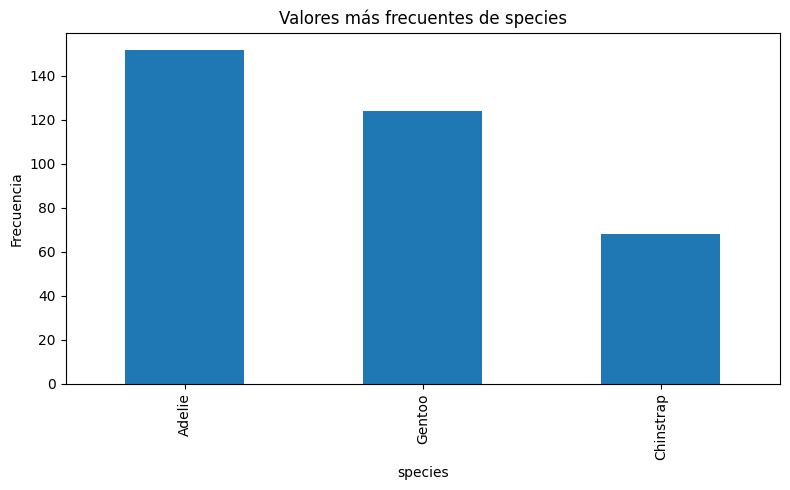

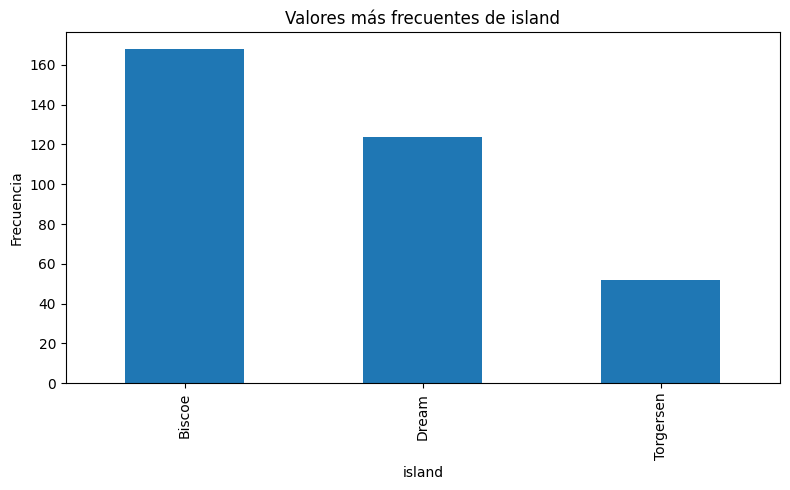

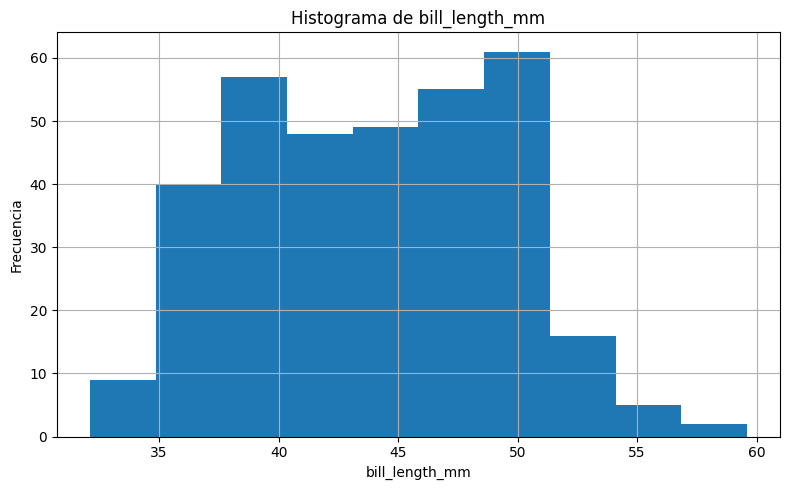

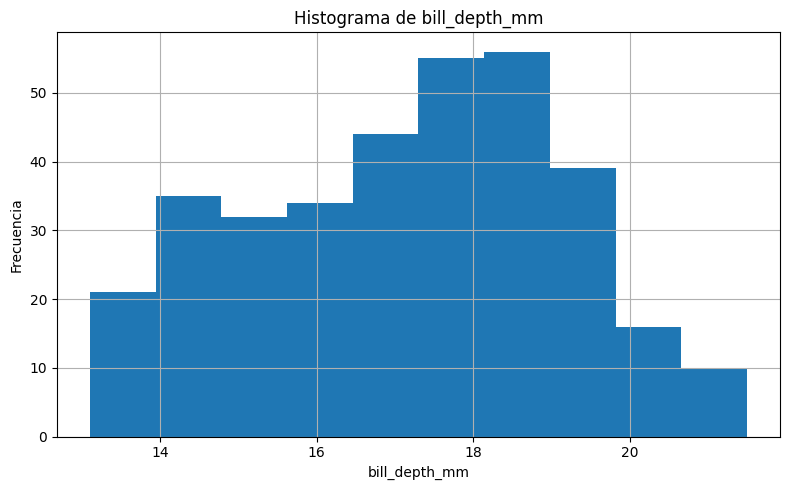

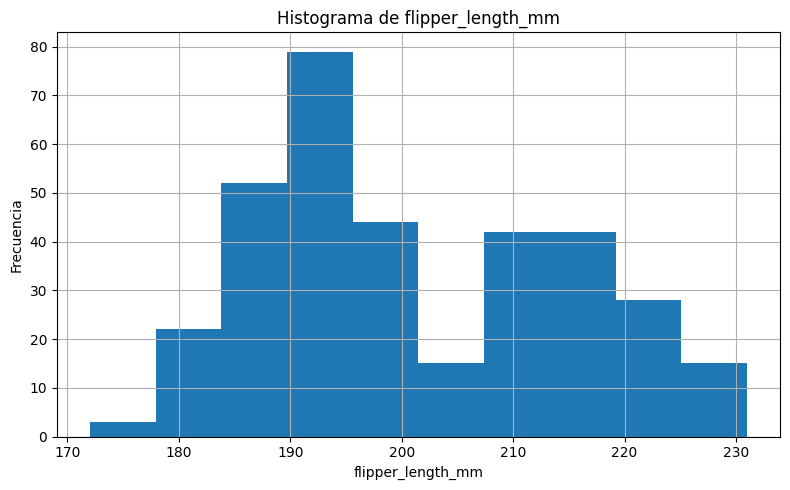

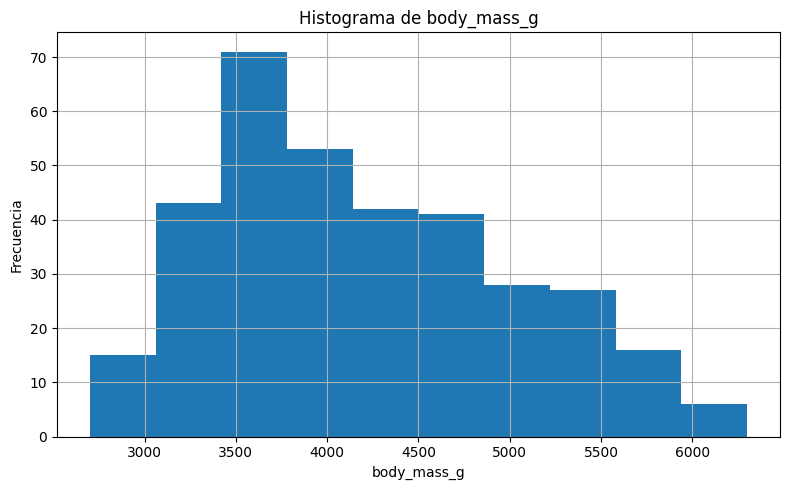

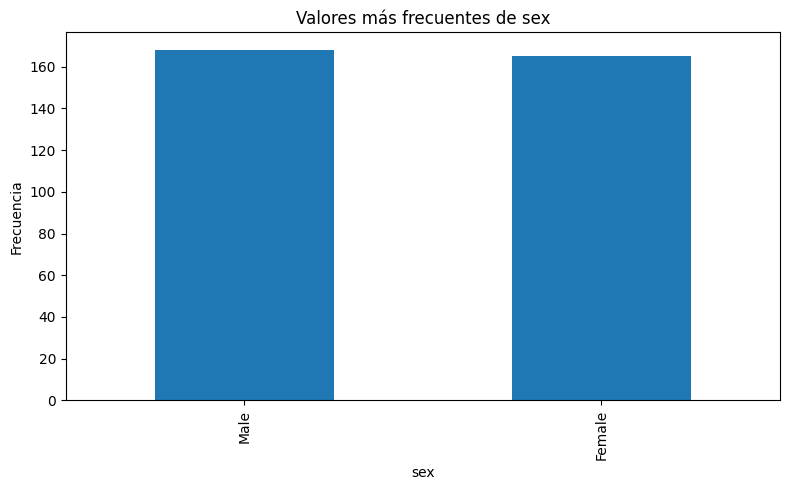

In [57]:
export_column_charts(penguins, charts_folder, show_charts=True)

In [58]:
list(charts_folder.iterdir())

[PosixPath('charts_sprint10/island.png'),
 PosixPath('charts_sprint10/flipper_length_mm.png'),
 PosixPath('charts_sprint10/bill_length_mm.png'),
 PosixPath('charts_sprint10/sex.png'),
 PosixPath('charts_sprint10/bill_depth_mm.png'),
 PosixPath('charts_sprint10/species.png'),
 PosixPath('charts_sprint10/body_mass_g.png')]

### Interpretación

La función permite hacer una primera revisión visual de un DataFrame de forma automática.

Al probarla con el dataset `penguins`, se generan gráficos para las columnas numéricas y categóricas sin tener que escribir un código distinto para cada columna.

Además, los gráficos se guardan en una carpeta y también se muestran dentro del notebook. Esto puede ser útil al inicio de un análisis, cuando quiero entender rápido qué tipo de variables tiene el dataset y cómo se distribuyen.

## Ejercicio 2: Ruta entre ciudades usando una matriz de distancias

El enunciado indica que la fuente original de la matriz de distancias es MejoresRutas.

En este notebook no extraigo los datos directamente desde la web, porque ya trabajo con el archivo `matriu_distancies.xlsx`.  
Esto hace que el ejercicio sea más reproducible y no dependa de una conexión web o de cambios en la página.

El objetivo es usar esta matriz para proponer una ruta entre ciudades, intentando recorrer la menor distancia posible con una aproximación sencilla.

In [59]:
distance_matrix = pd.read_excel(
    "matriu_distancies.xlsx",
    sheet_name="Distancia (kilómetros)",
    index_col=0
)

distance_matrix.head()

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0


In [60]:
display(distance_matrix.shape)

display(distance_matrix.index)

display(distance_matrix.columns)

(15, 15)

Index(['Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Málaga', 'Murcia',
       'Palma', 'Las Palmas de Gran Canaria', 'Bilbao', 'Alicante', 'Córdoba',
       'Valladolid', 'Vigo', 'Gijón', 'Hospitalet de Llobregat'],
      dtype='str')

Index(['Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Málaga', 'Murcia',
       'Palma', 'Las Palmas de Gran Canaria', 'Bilbao', 'Alicante', 'Córdoba',
       'Valladolid', 'Vigo', 'Gijón', 'Hospitalet de Llobregat'],
      dtype='str')

In [61]:
cities_to_remove = ["Las Palmas de Gran Canaria", "Palma"]

distance_matrix = distance_matrix.drop(
    index=cities_to_remove,
    columns=cities_to_remove,
    errors="ignore"
)

distance_matrix.head()

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0


In [62]:
distance_matrix = distance_matrix.apply(pd.to_numeric, errors="coerce")

distance_matrix.head()

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0


In [63]:
def proposar_ruta_propera(matriu_distancies, ciutat_origen):
    """
    Proposa una ruta visitant sempre la ciutat no visitada més propera.
    Retorna la ruta i la distància total recorreguda.
    """
    
    if ciutat_origen not in matriu_distancies.index:
        return {
            "error": "La ciutat d'origen no existeix a la matriu."
        }
    
    ciutats_no_visitades = set(matriu_distancies.index)
    ruta = [ciutat_origen]
    distancia_total = 0
    
    ciutat_actual = ciutat_origen
    ciutats_no_visitades.remove(ciutat_actual)
    
    while ciutats_no_visitades:
        distancies_possibles = matriu_distancies.loc[
            ciutat_actual,
            list(ciutats_no_visitades)
        ].dropna()
        
        ciutat_seguent = distancies_possibles.idxmin()
        distancia_seguent = distancies_possibles.min()
        
        ruta.append(ciutat_seguent)
        distancia_total += distancia_seguent
        
        ciutat_actual = ciutat_seguent
        ciutats_no_visitades.remove(ciutat_actual)
    
    return {
        "ruta": ruta,
        "distancia_total": distancia_total
    }

### Nota sobre el algoritmo

En este ejercicio uso una aproximación sencilla: desde la ciudad actual, voy siempre a la ciudad no visitada más cercana.

Este método no garantiza encontrar la ruta óptima, pero sí ofrece una solución razonable con las herramientas que estamos usando ahora.

La ventaja es que el algoritmo es fácil de entender y se puede aplicar directamente sobre la matriz de distancias.

In [64]:
start_city = "Barcelona"

route_result = proposar_ruta_propera(distance_matrix, start_city)

route_result

{'ruta': ['Barcelona',
  'Hospitalet de Llobregat',
  'Zaragoza',
  'Valencia',
  'Alicante',
  'Murcia',
  'Córdoba',
  'Sevilla',
  'Málaga',
  'Valladolid',
  'Gijón',
  'Bilbao',
  'Vigo'],
 'distancia_total': np.float64(2778.0)}

### Visualización alternativa de la ruta

Además de mostrar el resultado como un diccionario, también puedo convertir la ruta en una tabla para que sea más fácil de leer.

Esta visualización no cambia el resultado de la función; solo presenta la lista de ciudades de una forma más clara, con el orden de visita y la distancia total recorrida.

In [65]:
start_city = "Barcelona"

route_result = proposar_ruta_propera(distance_matrix, start_city)

route_df = pd.DataFrame({
    "Ordre de visita": range(1, len(route_result["ruta"]) + 1),
    "Ciutat": route_result["ruta"]
})

display(route_df.style.hide(axis="index"))

print(f"Ciutat d'origen: {start_city}")
print(f"Distància total recorreguda: {route_result['distancia_total']:.0f} km")

Ordre de visita,Ciutat
1,Barcelona
2,Hospitalet de Llobregat
3,Zaragoza
4,Valencia
5,Alicante
6,Murcia
7,Córdoba
8,Sevilla
9,Málaga
10,Valladolid


Ciutat d'origen: Barcelona
Distància total recorreguda: 2778 km


### Alternativa interactiva

También podría pedir la ciudad de origen al usuario con `input()`.

No uso esta opción como parte principal del notebook porque puede detener la ejecución automática del archivo, pero la dejo como alternativa.

```python
start_city = input("Escribe la ciudad de origen: ")

route_result = proposar_ruta_propera(distance_matrix, start_city)

route_df = pd.DataFrame({
    "Ordre de visita": range(1, len(route_result["ruta"]) + 1),
    "Ciutat": route_result["ruta"]
})

display(route_df.style.hide(axis="index"))

print(f"Ciutat d'origen: {start_city}")
print(f"Distància total recorreguda: {route_result['distancia_total']:.0f} km")
```

In [66]:
all_routes = []

for city in distance_matrix.index:
    result = proposar_ruta_propera(distance_matrix, city)
    
    all_routes.append({
        "ciutat_origen": city,
        "distancia_total": result["distancia_total"]
    })

routes_summary = pd.DataFrame(all_routes).sort_values(
    by="distancia_total",
    ascending=True
)

routes_summary

,ciutat_origen,distancia_total
0,Barcelona,2778.0
12,Hospitalet de Llobregat,2784.0
10,Vigo,2873.0
2,Sevilla,2956.0
8,Córdoba,2981.0
4,Málaga,3066.0
5,Murcia,3082.0
7,Alicante,3134.0
1,Valencia,3200.0
9,Valladolid,3357.0


In [67]:
best_start_city = routes_summary.iloc[0]["ciutat_origen"]
best_distance = routes_summary.iloc[0]["distancia_total"]

print(f"La ruta més curta amb aquest algoritme comença a {best_start_city}.")
print(f"Distància total: {best_distance:.0f} km")

La ruta més curta amb aquest algoritme comença a Barcelona.
Distància total: 2778 km


### Interpretación

Primero he cargado la matriz de distancias usando los nombres de las ciudades como filas y columnas.

Después he eliminado `Las Palmas de Gran Canaria` y `Palma`, porque el ejercicio plantea hacer el recorrido en coche.

La función creada empieza en una ciudad de origen y va eligiendo siempre la ciudad no visitada más cercana.  
Como resultado devuelve la ruta propuesta y la distancia total recorrida.

En la parte extra he probado el mismo algoritmo empezando desde cada ciudad.  
Así puedo comparar las distancias totales y ver desde qué ciudad la ruta queda más corta con esta aproximación.